In [131]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [132]:
odr = pd.read_csv("age-dependency-ratio-old.csv")
internet = pd.read_csv("share-of-individuals-using-the-internet.csv")
rd = pd.read_csv("research-spending-gdp.csv")
gdp_pc_long = pd.read_csv("gdp-per-capita-worldbank.csv")
tfp = pd.read_csv("total-factor-productivity.csv") 
patens = pd.read_csv("patent-applications-per-million.csv")
schooling = pd.read_csv("average-years-of-schooling-among-adults.csv")

In [133]:
odr = odr.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Age dependency ratio, old (% of working-age population)": "odr"
})

internet = internet.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Share of the population using the Internet": "internet_use"
})

gdp_pc_long = gdp_pc_long.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "GDP per capita": "gdppc",
})

rd = rd.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Research and development expenditure (% of GDP)": "rd"
})

tfp = tfp.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Total factor productivity level": "tfp"
})

patens = patens.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Patent applications per million people": "patens"
})

schooling = schooling.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Both genders": "schooling"
})

In [134]:
start = 2001
end = 2020

for df in [odr, tfp, rd, internet]:
    df["year"] = pd.to_numeric(df["year"], errors="coerce")

odr = odr[(odr["year"] >= start) & (odr["year"] <= end)]
tfp = tfp[(tfp["year"] >= start) & (tfp["year"] <= end)]
rd = rd[(rd["year"] >= start) & (rd["year"] <= end)]
internet = internet[(internet["year"] >= start) & (internet["year"] <= end)]
gdp_pc_long = gdp_pc_long[(gdp_pc_long["year"] >= start) & (gdp_pc_long["year"] <= end)]
patens = patens[(patens["year"] >= start) & (patens["year"] <= end)]

In [ ]:
panel2 = internet[["country", "code", "year", "internet_use"]].merge(
    odr[["code", "year", "odr"]],
    on=["code", "year"],
    how="inner"
)

panel2 = panel2.merge(
    rd[["code", "year", "rd"]],
    on=["code", "year"],
    how="inner"
)

panel2 = panel2.merge(
    gdp_pc_long[["code", "year", "gdppc"]],
    on=["code", "year"],
    how="inner"
)

panel2 = panel2.merge(
    tfp[["code", "year", "tfp"]],
    on=["code", "year"],
    how="inner"
)

panel2 = panel2.merge(
    patens[["code", "year", "patens"]],
    on=["code", "year"],
    how="inner"
)

panel2 = panel2.merge(
    schooling[["code", "year", "schooling"]],
    on=["code", "year"],
    how="inner"
)

panel2["log_gdp_pc"] = np.log(panel2["gdppc"])
panel2["log_internet_use"] = np.log(panel2["internet_use"])
panel2["log_tfp"] = np.log(panel2["tfp"])
panel2["log_patens"] = np.log(panel2["patens"])



    year  n_countries
0   2001           57
1   2002           60
2   2003           61
3   2004           61
4   2005           63
5   2006           61
6   2007           64
7   2008           68
8   2009           66
9   2010           66
10  2011           66
11  2012           64
12  2013           69
13  2014           65
14  2015           70
15  2016           67
16  2017           70
17  2018           72
18  2019           68
19  2020           69


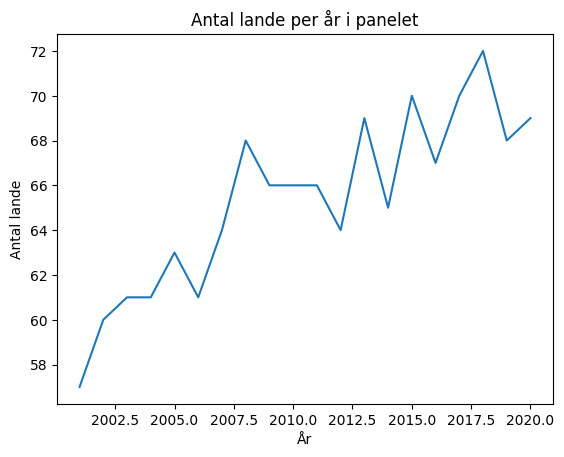

In [136]:
years_coverage = panel2.groupby("year")["code"].nunique().reset_index()
years_coverage = years_coverage.rename(columns={"code": "n_countries"})

print(years_coverage)

import matplotlib.pyplot as plt

plt.plot(years_coverage["year"], years_coverage["n_countries"])
plt.xlabel("År")
plt.ylabel("Antal lande")
plt.title("Antal lande per år i panelet")
plt.show()

In [144]:
print(panel2[["internet_use", "odr", "rd", "tfp", "gdppc", "schooling"]].isna().sum())

internet_use    0
odr             0
rd              0
tfp             0
gdppc           0
schooling       0
dtype: int64


In [138]:
# kopi af det færdige balanced panel
df_est = panel2.copy()

# lav log af BNP pr. capita
df_est["log_gdppc"] = np.log(df_est["gdppc"])

# estimation
model3 = smf.ols(
    "log_tfp ~ odr + log_gdppc + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr", "log_gdppc"]],
    "std_err": results3.bse[["odr", "log_gdppc"]],
    "p_value": results3.pvalues[["odr", "log_gdppc"]],
})

print(main_results3.round(4))

             coef  std_err  p_value
odr        0.0012   0.0034   0.7265
log_gdppc  0.5172   0.0534   0.0000


In [139]:
# kopi af det færdige balanced panel
df_est = panel2.copy()

# lav log af BNP pr. capita
df_est["log_gdppc"] = np.log(df_est["gdppc"])

# estimation
model3 = smf.ols(
    "log_tfp ~ odr + log_gdppc + log_internet_use + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr", "log_gdppc","log_internet_use"]],
    "std_err": results3.bse[["odr", "log_gdppc","log_internet_use"]],
    "p_value": results3.pvalues[["odr", "log_gdppc", "log_internet_use"]],
})

print(main_results3.round(4))

                    coef  std_err  p_value
odr               0.0052   0.0034   0.1307
log_gdppc         0.4729   0.0558   0.0000
log_internet_use  0.0298   0.0233   0.2009


In [140]:
# kopi af det færdige balanced panel
df_est = panel2.copy()

# lav log af BNP pr. capita
df_est["log_gdppc"] = np.log(df_est["gdppc"])

# estimation
model3 = smf.ols(
    "log_tfp ~ odr + log_gdppc + log_internet_use + patens + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr", "log_gdppc","log_internet_use", "patens"]],
    "std_err": results3.bse[["odr", "log_gdppc","log_internet_use", "patens"]],
    "p_value": results3.pvalues[["odr", "log_gdppc", "log_internet_use", "patens"]],
})

print(main_results3.round(4))

                    coef  std_err  p_value
odr               0.0045   0.0036   0.2111
log_gdppc         0.4852   0.0627   0.0000
log_internet_use  0.0277   0.0241   0.2503
patens           -0.0000   0.0000   0.3641


In [141]:
# kopi af det færdige balanced panel
df_est = panel2.copy()

# lav log af BNP pr. capita
df_est["log_gdppc"] = np.log(df_est["gdppc"])

# estimation
model3 = smf.ols(
    "tfp ~ odr + log_gdppc + log_internet_use + patens + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr", "log_gdppc","log_internet_use", "patens"]],
    "std_err": results3.bse[["odr", "log_gdppc","log_internet_use", "patens"]],
    "p_value": results3.pvalues[["odr", "log_gdppc", "log_internet_use", "patens"]],
})

print(main_results3.round(4))

                    coef  std_err  p_value
odr               0.0028   0.0033   0.3998
log_gdppc         0.4555   0.0588   0.0000
log_internet_use  0.0016   0.0140   0.9082
patens           -0.0000   0.0000   0.2118


In [142]:
# kopi af det færdige balanced panel
df_est = panel2.copy()

# lav log af BNP pr. capita
df_est["log_gdppc"] = np.log(df_est["gdppc"])

# estimation
model3 = smf.ols(
    "tfp ~ odr  + log_internet_use + patens + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr","log_internet_use", "patens"]],
    "std_err": results3.bse[["odr", "log_internet_use", "patens"]],
    "p_value": results3.pvalues[["odr", "log_internet_use", "patens"]],
})

print(main_results3.round(4))

                    coef  std_err  p_value
odr               0.0082   0.0043   0.0580
log_internet_use  0.0562   0.0115   0.0000
patens            0.0001   0.0000   0.0186


In [143]:
# kopi af det færdige balanced panel
df_est = panel2.copy()

# lav log af BNP pr. capita
df_est["log_gdppc"] = np.log(df_est["gdppc"])

# estimation
model3 = smf.ols(
    "tfp ~ odr  + log_internet_use + log_patens + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr","log_internet_use", "log_patens"]],
    "std_err": results3.bse[["odr", "log_internet_use", "log_patens"]],
    "p_value": results3.pvalues[["odr", "log_internet_use", "log_patens"]],
})

print(main_results3.round(4))

                    coef  std_err  p_value
odr               0.0063   0.0045   0.1608
log_internet_use  0.0535   0.0124   0.0000
log_patens       -0.0131   0.0158   0.4076


In [145]:
# kopi af det færdige balanced panel
df_est = panel2.copy()

# lav log af BNP pr. capita
df_est["log_gdppc"] = np.log(df_est["gdppc"])

# estimation
model3 = smf.ols(
    "tfp ~ odr  + log_internet_use + log_patens + schooling + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr","log_internet_use", "log_patens", "schooling"]],
    "std_err": results3.bse[["odr", "log_internet_use", "log_patens", "schooling"]],
    "p_value": results3.pvalues[["odr", "log_internet_use", "log_patens", "schooling"]],
})

print(main_results3.round(4))

                    coef  std_err  p_value
odr               0.0045   0.0044   0.3115
log_internet_use  0.0520   0.0125   0.0000
log_patens       -0.0089   0.0147   0.5449
schooling        -0.0339   0.0197   0.0854


In [148]:
# kopi af det færdige balanced panel
df_est = panel2.copy()

# lav log af BNP pr. capita
df_est["log_gdppc"] = np.log(df_est["gdppc"])

# estimation
model3 = smf.ols(
    "log_tfp ~ odr  + log_internet_use + patens + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr","log_internet_use", "patens"]],
    "std_err": results3.bse[["odr", "log_internet_use", "patens"]],
    "p_value": results3.pvalues[["odr", "log_internet_use", "patens"]],
})

print(main_results3.round(4))

                    coef  std_err  p_value
odr               0.0103   0.0044   0.0193
log_internet_use  0.0859   0.0172   0.0000
patens            0.0001   0.0001   0.0257
